# 12. 계약조건별 공정가 증분 — DART 공시가 원시 분석

**대상은 모델도 MC 도 아닌 DART 공시 원문의 공정가치**다. `fair = FAIR_VALUE / ISU_PRC_DETAIL`
(`module/build_source.py`), 즉 발행가 대비 비율이고 발행가 10,000원 기준으로 환산해 **원 단위 증분**으로 본다.

묻는 것은 하나다 — **계약조건이 한 단위 움직일 때 공시 공정가는 얼마나 움직이며, 그 증분이 기준을 바꿔도 유지되는가.**
수준(level) 그림은 맥락용이고, 모든 절의 산출물은 증분 `Δfair / Δterm` 이다.

증분을 쪼개는 기준: **발행연도 · 상품구조 · 변동성 레짐 · 상관 레짐 · 금리 레짐 · 발행사**.

## 두 가지 증분을 나란히 본다

- **단변량 증분** — `fair` 를 조건에 그냥 회귀한 기울기. 발행사가 시장을 보고 조건을 *동시에* 정하므로 교란된다.
- **부분 증분** — 시장상태(σ_eff·ρ·r·curve_level·recent_mktvol)와 **발행사·발행분기 고정효과**를 제거한 뒤의 기울기.

다른 계약조건은 통제하지 **않는다**. 조건끼리 상관이 0.98(`b_over_k`↔`B`)·0.87(`coupon`↔`cpn_spread`)·
−0.77(`B`↔`K`)까지 가서, 서로를 통제하면 계수가 공선성으로 폭주하고 해석도 "다른 조건을 고정한 채"라는
데이터에 거의 없는 반사실이 된다. 그래서 **시장·발행사·시점만 제거**한다.

> **한계를 먼저 명시한다.** 이건 관측 데이터라 여기서 나오는 기울기는 **조건부 연관**이지 가격 미분(그리스)이
> 아니다. 쿠폰만 다르고 나머지가 같은 두 계약은 데이터에 거의 없다. 진짜 미분을 보려면 한 항만 흔들고
> 나머지를 고정해 재가격해야 하며, 그건 이 노트북의 범위 밖이다.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from util import file_manager as fm, plot as _plot     # import 만으로 dpi400·투명·PPT 밴드 적용

FACE = 10000
df = pd.read_parquet(fm.source())
df["date"] = df.isu_ord.map(lambda o: pd.Timestamp.fromordinal(int(o)))
df["year"] = df.date.dt.year
df["yq"] = df.date.dt.to_period("Q").astype(str)
df["struct"] = df.opt_type.astype(str) + " x " + np.where(df.ki_yn.astype(int) == 1, "KI", "no-KI")

# 조건별 '한 단위' — 해석 가능한 크기로 (증분은 이 단위당 원)
UNIT = {"B": (0.05, "barrier +5%p"),        "K": (0.05, "final strike +5%p"),
        "Kfirst": (0.05, "first strike +5%p"), "stepdown": (0.05, "step-down +5%p"),
        "coupon": (0.01, "coupon +1%p"),    "cpn_spread": (0.01, "coupon spread +1%p"),
        "nobs": (1.0, "+1 observation"),    "b_over_k": (0.10, "B/K +0.1")}
TERMS = list(UNIT)
KI_ONLY = {"B", "b_over_k"}          # no-KI 는 B 가 정확히 1.000 -> 그 안에서 변동이 없다

# 8개 중 3개는 다른 조건의 **결정론적 함수**다 (module/build_source.py:142-143).
#   cpn_spread = coupon - r   /   b_over_k = B / K   /   stepdown = Kfirst - K
# 따라서 독립적인 계약조건은 5개뿐이고, 파생항의 증분은 '요약 지표의 증분'으로 읽어야 한다.
DERIVED_OF = {"cpn_spread": "coupon - r", "b_over_k": "B / K", "stepdown": "Kfirst - K"}
PRIMARY = [t for t in TERMS if t not in DERIVED_OF]
DERIVED = [t for t in TERMS if t in DERIVED_OF]
CTRL = ["sig_eff", "rho", "r", "curve_level", "recent_mktvol"]

# 레짐 3분위 (기준 축)
for c, nm in [("sig_eff", "vol"), ("rho", "corr"), ("curve_level", "rate")]:
    df[f"{nm}_reg"] = pd.qcut(df[c], 3, labels=[f"{nm} low", f"{nm} mid", f"{nm} high"]).astype(str)
TOP_ISSUER = df.issuer.value_counts().head(6).index.tolist()

print(f"공시 계약 {len(df):,}건 | 발행 {df.date.min().date()} ~ {df.date.max().date()} | 발행사 {df.issuer.nunique()}")
print(f"fair (공시 공정가/발행가) mean={df.fair.mean():.4f} sd={df.fair.std():.4f} "
      f"-> 원 단위 {df.fair.mean()*FACE:,.0f}원 (발행가 {FACE:,}원)")
print(df.groupby("struct").agg(n=("fair", "size"), fair_mean=("fair", "mean")).round(4).to_string())

공시 계약 58,790건 | 발행 2015-01-05 ~ 2026-05-12 | 발행사 23
fair (공시 공정가/발행가) mean=0.9293 sd=0.0468 -> 원 단위 9,293원 (발행가 10,000원)
                    n  fair_mean
struct                          
LIZARD x KI      1781     0.9158
LIZARD x no-KI   9880     0.9302
STEP x KI       23081     0.9312
STEP x no-KI    24048     0.9280


In [2]:
# ---- 증분 추정기 --------------------------------------------------------------
def _residualize(d, cols):
    """(발행사 x 발행분기) 셀 평균제거 -> 시장상태 통제변수에 OLS 잔차화. FWL 부분기울기용."""
    key = (d.issuer.astype(str) + "|" + d.yq).values
    M = d[cols].astype(float)
    M = (M - M.groupby(key).transform("mean")).values
    C = d[CTRL].astype(float)
    C = (C - C.groupby(key).transform("mean")).values
    C = np.c_[C, np.ones(len(C))]
    coef, *_ = np.linalg.lstsq(C, M, rcond=None)
    return pd.DataFrame(M - C @ coef, columns=cols, index=d.index)


def _slope(y, x, cluster):
    """기울기 + 발행일 클러스터 강건 표준오차 (같은 날 발행분은 시장충격을 공유한다)."""
    x = x - x.mean(); y = y - y.mean()
    sxx = float((x * x).sum())
    if sxx <= 1e-12:
        return np.nan, np.nan
    b = float((x * y).sum() / sxx)
    e = y - b * x
    g = pd.Series(x * e).groupby(np.asarray(cluster)).sum().values
    return b, float(np.sqrt((g ** 2).sum()) / sxx)


def slopes(d, kind="partial", min_n=400, min_sd=1e-6):
    """한 그룹에서 전 조건의 증분(원/단위). kind='uni'|'partial'."""
    use = [t for t in TERMS if not (t in KI_ONLY and (d.ki_yn.astype(int) == 0).all())]
    g = d.dropna(subset=use + ["fair"] + CTRL)
    if len(g) < min_n:
        return pd.DataFrame()
    R = _residualize(g, ["fair"] + use) if kind == "partial" else None
    out = []
    for t in use:
        x = (R[t] if kind == "partial" else g[t].astype(float)).values
        y = (R["fair"] if kind == "partial" else g["fair"].astype(float)).values
        if np.std(x) < min_sd:
            continue
        b, se = _slope(y, x, g.isu_ord.values)
        u = UNIT[t][0]
        out.append({"term": t, "kind": kind, "n": len(g),
                    "slope": b * u * FACE, "se": se * u * FACE})
    return pd.DataFrame(out)


def slopes_by(basis, col, values=None, subset=None):
    """기준 축(basis) 의 각 그룹에서 단변량·부분 증분을 모두 계산해 long 표로."""
    src = df if subset is None else subset
    vals = values if values is not None else sorted(src[col].dropna().unique())
    rows = []
    for v in vals:
        d = src[src[col] == v]
        for kind in ("uni", "partial"):
            s = slopes(d, kind)
            if len(s):
                s["basis"] = basis; s["group"] = str(v)
                rows.append(s)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


print("증분 추정기 준비 완료 — 단위:", {k: v[1] for k, v in UNIT.items()})

증분 추정기 준비 완료 — 단위: {'B': 'barrier +5%p', 'K': 'final strike +5%p', 'Kfirst': 'first strike +5%p', 'stepdown': 'step-down +5%p', 'coupon': 'coupon +1%p', 'cpn_spread': 'coupon spread +1%p', 'nobs': '+1 observation', 'b_over_k': 'B/K +0.1'}


## 12-1. 무엇이 식별 가능한가 — 조건 간 교란 구조

증분을 말하기 전에 **말할 수 있는 조건이 무엇인지** 부터 정한다. 세 가지가 걸린다.

- `tenor` 는 **99.0% 가 3.0년** 이라 변동이 없다 → 증분 추정 대상에서 제외한다.
- `B` 는 no-KI 가 **정확히 1.000**(33,928건), KI 가 0.25~0.65(24,862건) 인 **이봉** 이다 → `B`·`b_over_k` 는 KI 안에서만 본다.
- 조건끼리 상관이 크다(`b_over_k`↔`B` 0.98). 서로를 통제하지 않는 이유가 이것이다.

**그리고 8개 중 3개는 아예 다른 조건의 결정론적 함수다** (`module/build_source.py:142-143`).

| 파생 조건 | 항등식 |
|---|---|
| `cpn_spread` | `coupon − r` (정확히 일치) |
| `b_over_k` | `B / K` |
| `stepdown` | `Kfirst − K` |

그래서 **독립적인 계약조건은 `B`·`K`·`Kfirst`·`coupon`·`nobs` 5개뿐**이다. 파생항의 증분은 새로운 정보가
아니라 원 조건들의 조합을 다르게 요약한 값으로 읽어야 한다. 특히 `r` 을 통제변수에 넣었으므로
**부분증분에서 `cpn_spread` 는 `coupon` 과 수치적으로 동일해진다** — 아래 표에서 두 값이 같은 것은
버그가 아니라 항등식의 결과다.


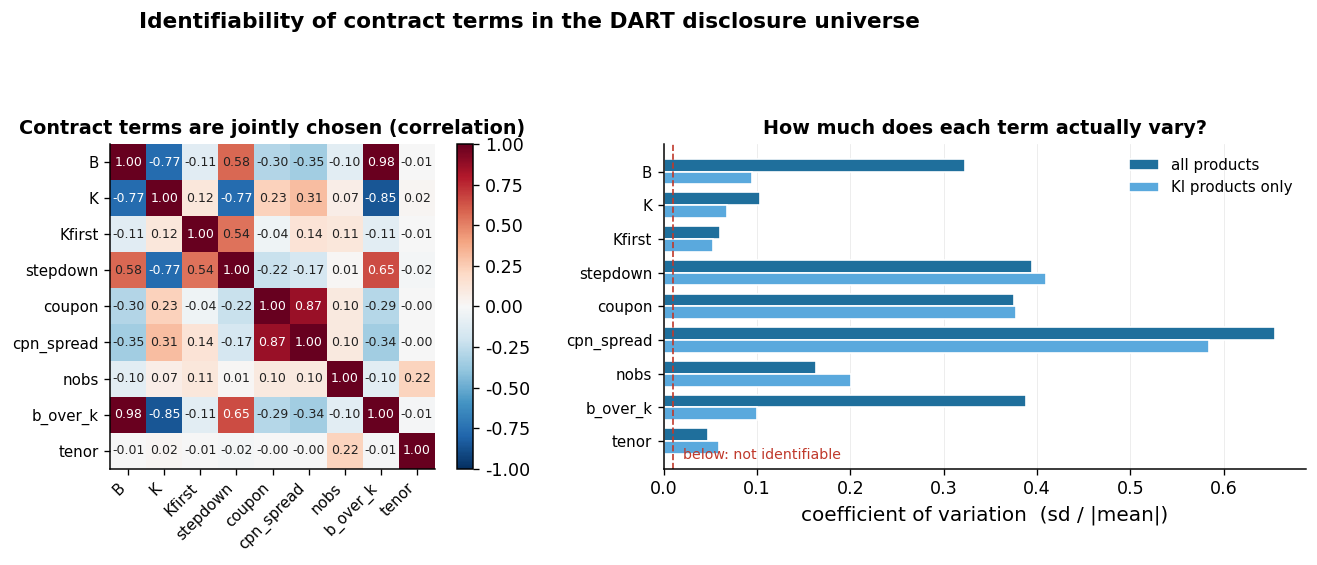

tenor: 99.0% 가 3.0년 -> 증분 추정 제외
B: no-KI 33,928건 전부 1.000 / KI 24,862건 0.25~0.65

=== 파생 항등식 검증 ===
  cpn_spread  = coupon - r    일치: True   (max |diff| = 0.00e+00)
  b_over_k    = B / K         일치: True   (max |diff| = 0.00e+00)
  stepdown    = Kfirst - K    일치: True   (max |diff| = 0.00e+00)
독립 조건 5개: ['B', 'K', 'Kfirst', 'coupon', 'nobs']   /  파생 3개: ['stepdown', 'cpn_spread', 'b_over_k']
saved -> ct_identifiability.png | ct_identifiability.csv


In [3]:
# 그림 1: 계약조건 상호상관 + 조건별 변동성(식별 가능성)
fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8),
                       gridspec_kw={"width_ratios": [1.15, 1]})
COR = df[TERMS + ["tenor"]].corr()
im = ax[0].imshow(COR.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_xticks(range(len(COR))); ax[0].set_xticklabels(COR.columns, rotation=45, ha="right", fontsize=9)
ax[0].set_yticks(range(len(COR))); ax[0].set_yticklabels(COR.columns, fontsize=9)
for i in range(len(COR)):
    for j in range(len(COR)):
        v = COR.values[i, j]
        ax[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                   color="white" if abs(v) > .6 else "#222")
ax[0].set_title("Contract terms are jointly chosen (correlation)", fontsize=11.5)
fig.colorbar(im, ax=ax[0], fraction=.046, pad=.03)

# 조건별 변동계수 = sd / |mean| (전체 vs KI 내부) — 식별 가능성
rows = []
for t in TERMS + ["tenor"]:
    s = df[t].astype(float); k = df.loc[df.ki_yn.astype(int) == 1, t].astype(float)
    rows.append({"term": t, "all": s.std() / (abs(s.mean()) + 1e-12),
                 "KI only": k.std() / (abs(k.mean()) + 1e-12)})
IDF = pd.DataFrame(rows).set_index("term")
y = np.arange(len(IDF)); w = .38
ax[1].barh(y - w/2, IDF["all"], w, label="all products", color=_plot._QUAL[0], edgecolor="white")
ax[1].barh(y + w/2, IDF["KI only"], w, label="KI products only", color=_plot._QUAL[1], edgecolor="white")
ax[1].set_yticks(y); ax[1].set_yticklabels(IDF.index, fontsize=9); ax[1].invert_yaxis()
ax[1].set_xlabel("coefficient of variation  (sd / |mean|)")
ax[1].set_title("How much does each term actually vary?", fontsize=11.5)
ax[1].legend(fontsize=9); ax[1].grid(axis="x", color="#dddddd", lw=.5, alpha=.6)
ax[1].axvline(0.01, color="#c0392b", lw=1.0, ls="--")
ax[1].text(0.011, len(IDF) - .6, "  below: not identifiable", color="#c0392b", fontsize=8.5, va="center")

fig.suptitle("Identifiability of contract terms in the DART disclosure universe",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(fm.image("ct_identifiability")); plt.show()
IDF.round(4).to_csv(fm.stat("ct_identifiability"))
print(f"tenor: {(df.tenor.round(1) == 3.0).mean()*100:.1f}% 가 3.0년 -> 증분 추정 제외")
print(f"B: no-KI {int((df.ki_yn==0).sum()):,}건 전부 1.000 / KI {int((df.ki_yn==1).sum()):,}건 "
      f"{df.loc[df.ki_yn==1,'B'].min():.2f}~{df.loc[df.ki_yn==1,'B'].max():.2f}")
print("\n=== 파생 항등식 검증 ===")
for t, expr in DERIVED_OF.items():
    val = {"cpn_spread": df.coupon - df.r, "b_over_k": df.B / df.K,
           "stepdown": df.Kfirst - df.K}[t]
    ok = np.allclose(df[t], val, atol=1e-8, equal_nan=True)
    print(f"  {t:11s} = {expr:12s}  일치: {ok}   (max |diff| = {float((df[t]-val).abs().max()):.2e})")
print(f"독립 조건 {len(PRIMARY)}개: {PRIMARY}   /  파생 {len(DERIVED)}개: {DERIVED}")
print("saved ->", fm.image("ct_identifiability").name, "|", fm.stat("ct_identifiability").name)

## 12-2. 수준(level) — 조건별 공시 공정가 반응곡선

증분으로 넘어가기 전 맥락. 구간평균 ± IQR 이고 회색 막대가 표본 수다.
**부호가 이론과 어긋나 보이는 구간**이 곧 교란이 큰 지점이다.


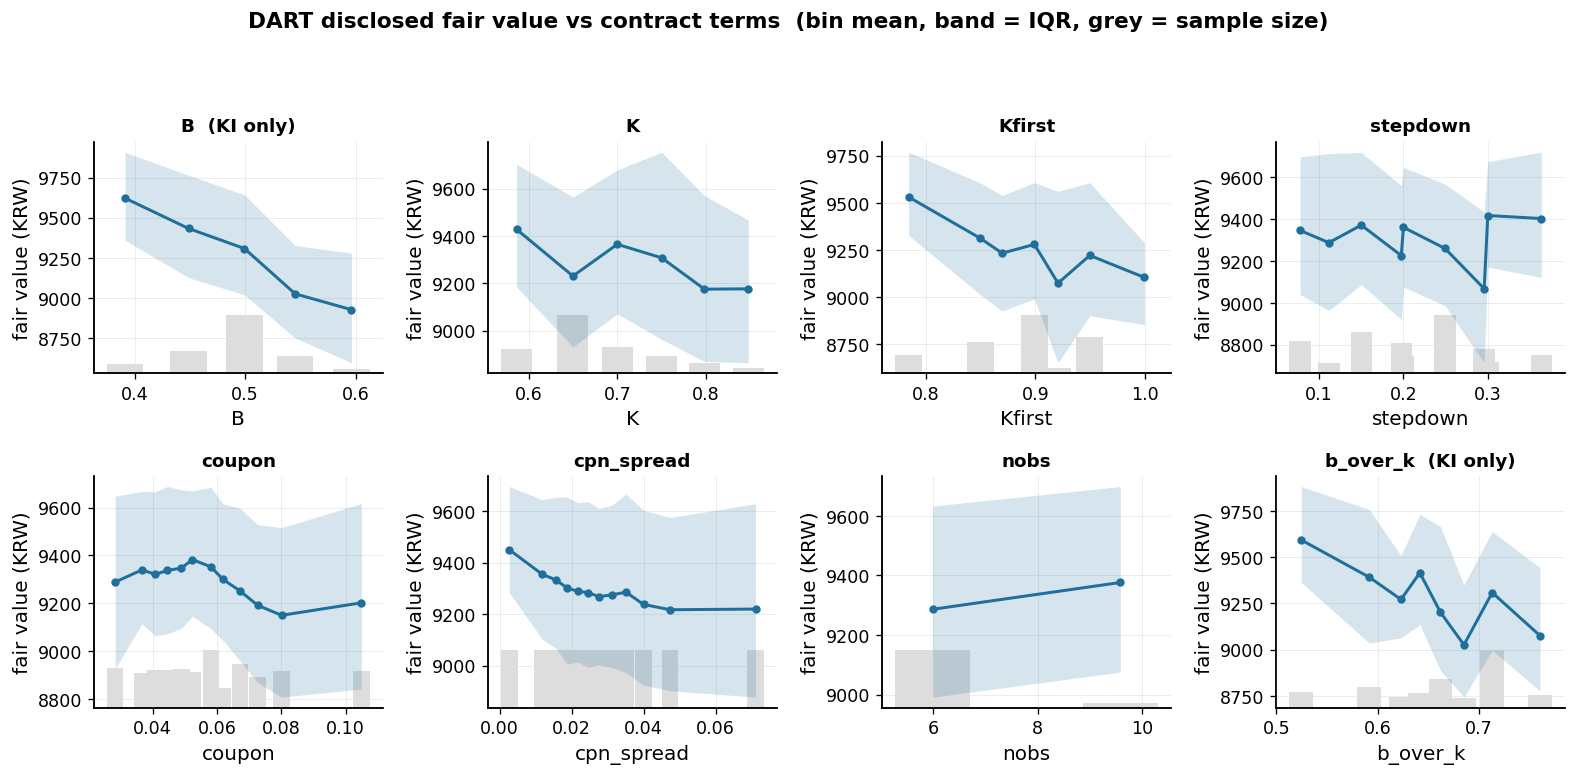

saved -> ct_level_curves.png


In [4]:
# 그림 2: 조건별 공시 공정가 반응곡선 (구간평균 ± IQR + 표본수)
fig, axs = plt.subplots(2, 4, figsize=(_plot.SLIDE_W, 6.6))
for a, t in zip(axs.ravel(), TERMS):
    d = df[df.ki_yn.astype(int) == 1] if t in KI_ONLY else df
    x = d[t].astype(float)
    q = min(12, x.nunique())
    b = pd.qcut(x, q, duplicates="drop")
    g = d.groupby(b, observed=True)["fair"]
    cx = d.groupby(b, observed=True)[t].mean().values
    mu = g.mean().values * FACE
    lo = g.quantile(.25).values * FACE; hi = g.quantile(.75).values * FACE
    n = g.size().values

    a2 = a.twinx()
    a2.bar(cx, n, width=(cx.max()-cx.min())/max(len(cx), 1)*.8, color="#dddddd", zorder=0)
    a2.set_ylim(0, n.max()*4); a2.set_yticks([]); a2.spines["right"].set_visible(False)

    a.fill_between(cx, lo, hi, color=_plot._QUAL[0], alpha=.18, zorder=2, linewidth=0)
    a.plot(cx, mu, "o-", ms=4, lw=1.8, color=_plot._QUAL[0], zorder=3)
    a.set_zorder(a2.get_zorder()+1); a.patch.set_visible(False)
    a.set_title(f"{t}" + ("  (KI only)" if t in KI_ONLY else ""), fontsize=11)
    a.set_xlabel(t); a.set_ylabel("fair value (KRW)")
    a.grid(color="#dddddd", lw=.5, alpha=.6)
fig.suptitle("DART disclosed fair value vs contract terms  (bin mean, band = IQR, grey = sample size)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("ct_level_curves")); plt.show()
print("saved ->", fm.image("ct_level_curves").name)

## 12-3. 증분 — 단변량 vs 부분

같은 조건에 대해 **교란된 증분**과 **시장·발행사·시점을 제거한 증분**을 나란히 놓는다.
두 막대의 간격이 곧 **교란의 크기**다. 오차봉은 발행일 클러스터 강건 95% 구간이다.


=== 전체 표본 증분 (원 / 단위, 발행가 10,000원) ===
                          unit     derived           uni      partial
term                                                                 
B                 barrier +5%p           -  -171.3 ±10.3  -156.2 ±5.0
K            final strike +5%p           -    -29.9 ±4.7    -7.4 ±2.3
Kfirst       first strike +5%p           -    -86.8 ±7.2  -106.2 ±3.4
stepdown        step-down +5%p  Kfirst - K    -14.6 ±4.2   -33.5 ±2.3
coupon             coupon +1%p           -    -20.4 ±6.5   -68.8 ±3.6
cpn_spread  coupon spread +1%p  coupon - r    -26.8 ±6.3   -68.8 ±3.6
nobs            +1 observation           -     22.7 ±4.6    16.3 ±2.4
b_over_k              B/K +0.1       B / K  -145.3 ±14.6  -111.7 ±8.4

  * derived 열이 채워진 행은 원 조건의 결정론적 함수다.
  * r 을 통제하므로 부분증분에서 cpn_spread 는 coupon 과 정확히 같아진다 (항등식 결과).


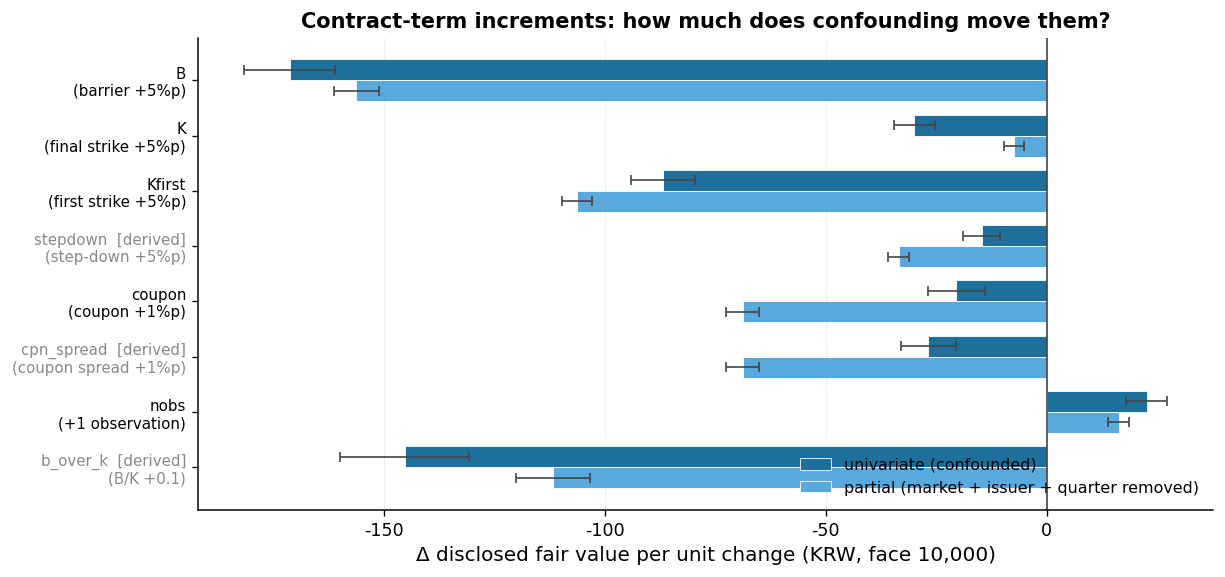

saved -> ct_slope_uni_vs_partial.png | ct_slope_overall.csv


In [5]:
# 전체 표본 증분 (단변량 vs 부분). B 계열은 KI 안에서만 변동하므로 KI 서브셋으로 계산한다.
KI = df[df.ki_yn.astype(int) == 1]
parts = []
for kind in ("uni", "partial"):
    full = slopes(df, kind)
    full = full[~full.term.isin(KI_ONLY)]          # 전체 표본: B 계열 제외
    ki = slopes(KI, kind)
    ki = ki[ki.term.isin(KI_ONLY)]                 # KI 서브셋: B 계열만
    parts += [full, ki]
ALL = pd.concat(parts, ignore_index=True)
ALL["derived_of"] = ALL.term.map(DERIVED_OF).fillna("")
ALL.to_csv(fm.stat("ct_slope_overall"), index=False)

P = ALL.pivot(index="term", columns="kind", values="slope").loc[TERMS]
E = ALL.pivot(index="term", columns="kind", values="se").loc[TERMS]
print("=== 전체 표본 증분 (원 / 단위, 발행가 10,000원) ===")
show = pd.DataFrame({"unit": [UNIT[t][1] for t in P.index],
                     "derived": [DERIVED_OF.get(t, "-") for t in P.index],
                     "uni": P["uni"].round(1).astype(str) + " ±" + (1.96*E["uni"]).round(1).astype(str),
                     "partial": P["partial"].round(1).astype(str) + " ±" + (1.96*E["partial"]).round(1).astype(str)})
print(show.to_string())
print("\n  * derived 열이 채워진 행은 원 조건의 결정론적 함수다.")
print("  * r 을 통제하므로 부분증분에서 cpn_spread 는 coupon 과 정확히 같아진다 (항등식 결과).")

fig, a = plt.subplots(figsize=(_plot.SLIDE_W*.78, 5.0))
y = np.arange(len(P)); w = .38
for j, kind in enumerate(["uni", "partial"]):
    a.barh(y + (j-.5)*w, P[kind].values, w, xerr=1.96*E[kind].values,
           label={"uni": "univariate (confounded)",
                  "partial": "partial (market + issuer + quarter removed)"}[kind],
           color=_plot._QUAL[j], edgecolor="white", linewidth=.5,
           error_kw=dict(ecolor="#444", lw=1.0, capsize=3))
a.set_yticks(y)
a.set_yticklabels([f"{t}{'  [derived]' if t in DERIVED_OF else ''}\n({UNIT[t][1]})" for t in P.index],
                  fontsize=9)
for i, t in enumerate(P.index):                       # 파생항은 라벨을 회색으로
    if t in DERIVED_OF:
        a.get_yticklabels()[i].set_color("#888888")
a.invert_yaxis(); a.axvline(0, color="#444", lw=1.0)
a.set_xlabel("Δ disclosed fair value per unit change (KRW, face 10,000)")
a.set_title("Contract-term increments: how much does confounding move them?", fontsize=12.5)
a.legend(fontsize=9.5, loc="lower right"); a.grid(axis="x", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("ct_slope_uni_vs_partial")); plt.show()
print("saved ->", fm.image("ct_slope_uni_vs_partial").name, "|", fm.stat("ct_slope_overall").name)

## 12-4. 기간별 증분 — 발행연도에 따라 유지되는가

**요청하신 핵심 축.** 조건마다 발행연도별 부분증분을 추정해 부호와 크기가 유지되는지 본다.
음영은 95% 구간이고, 0선을 가로지르는 해가 곧 그 해에는 증분이 확인되지 않는다는 뜻이다.


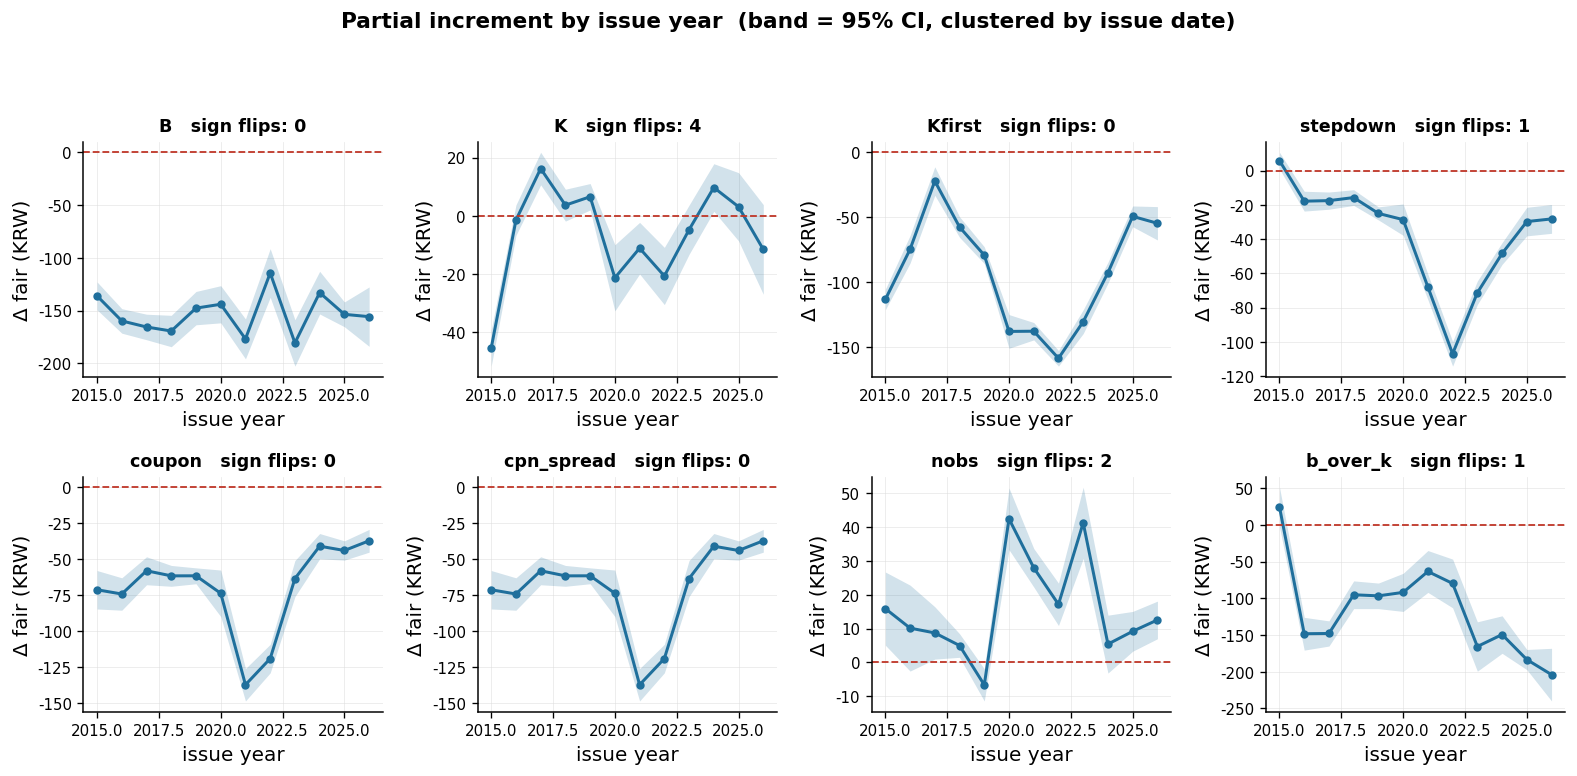

saved -> ct_slope_by_year.png | ct_slope_by_year.csv


In [6]:
# 발행연도별 증분
YRS = [y for y in sorted(df.year.unique()) if (df.year == y).sum() >= 800]
BY_YEAR = slopes_by("year", "year", YRS)
BY_YEAR_KI = slopes_by("year", "year", YRS, subset=KI)
for t in KI_ONLY:                      # B 계열은 KI 서브셋 결과로 교체
    BY_YEAR = BY_YEAR[BY_YEAR.term != t]
BY_YEAR = pd.concat([BY_YEAR, BY_YEAR_KI[BY_YEAR_KI.term.isin(KI_ONLY)]], ignore_index=True)
BY_YEAR.to_csv(fm.stat("ct_slope_by_year"), index=False)

fig, axs = plt.subplots(2, 4, figsize=(_plot.SLIDE_W, 6.6))
for a, t in zip(axs.ravel(), TERMS):
    s = BY_YEAR[(BY_YEAR.term == t) & (BY_YEAR.kind == "partial")].sort_values("group")
    if not len(s):
        a.axis("off"); continue
    x = s.group.astype(int).values; b = s.slope.values; e = 1.96*s.se.values
    a.fill_between(x, b-e, b+e, color=_plot._QUAL[0], alpha=.20, linewidth=0)
    a.plot(x, b, "o-", ms=4, lw=1.8, color=_plot._QUAL[0])
    a.axhline(0, color="#c0392b", lw=1.1, ls="--")
    flip = int(((b[:-1]*b[1:]) < 0).sum())
    a.set_title(f"{t}   sign flips: {flip}", fontsize=10.5)
    a.set_xlabel("issue year"); a.set_ylabel("Δ fair (KRW)")
    a.grid(color="#dddddd", lw=.5, alpha=.6); a.tick_params(labelsize=9)
fig.suptitle("Partial increment by issue year  (band = 95% CI, clustered by issue date)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(fm.image("ct_slope_by_year")); plt.show()
print("saved ->", fm.image("ct_slope_by_year").name, "|", fm.stat("ct_slope_by_year").name)

## 12-5. 다중 기준 증분 히트맵 — 어떤 기준에서 증분이 뒤집히는가

행이 계약조건, 열이 기준 그룹, 셀이 부분증분(원/단위)이다. **색이 부호, 진하기가 크기**이고
95% 구간이 0을 포함하면 회색 사선으로 덮어 "확인되지 않음"을 표시한다.


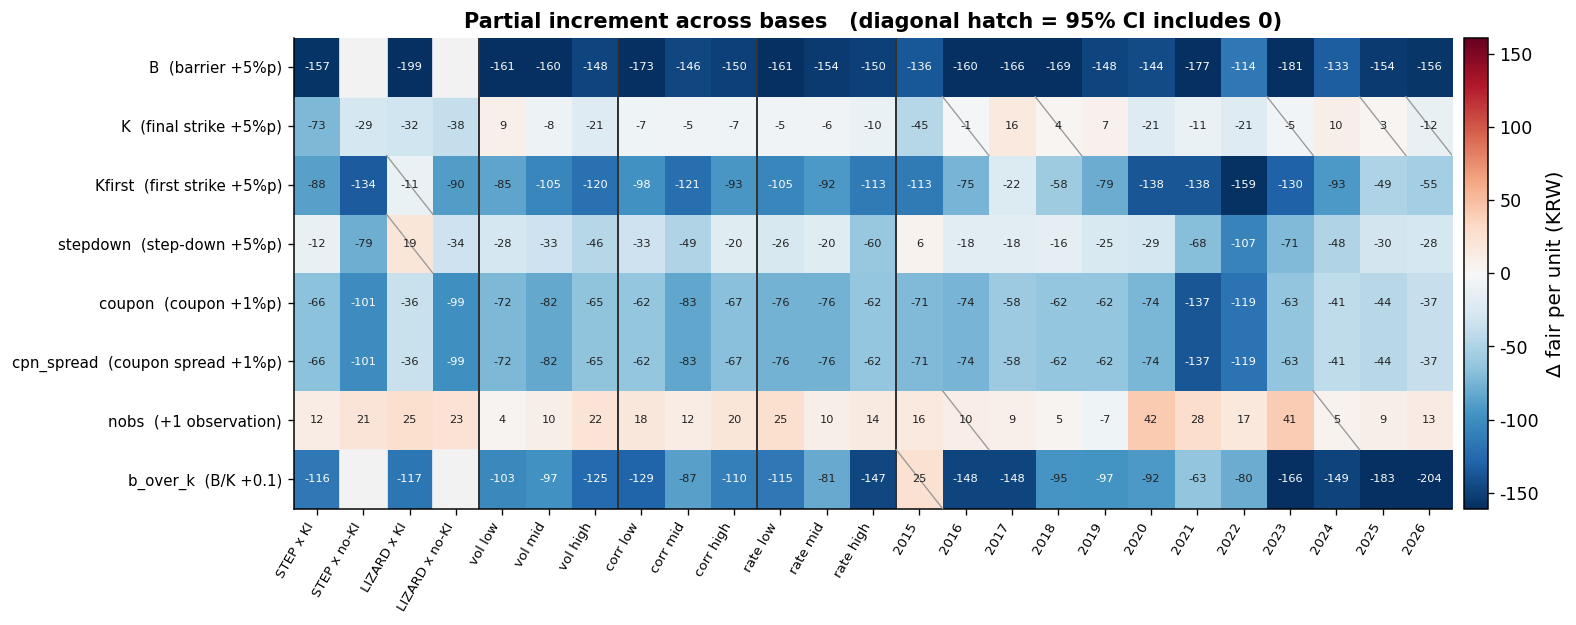

saved -> ct_slope_heatmap.png | ct_slope_all_bases.csv


In [7]:
# 여러 기준에서 한꺼번에 증분 계산
BASES = []
BASES.append(slopes_by("structure", "struct"))
BASES.append(slopes_by("vol regime", "vol_reg", ["vol low", "vol mid", "vol high"]))
BASES.append(slopes_by("corr regime", "corr_reg", ["corr low", "corr mid", "corr high"]))
BASES.append(slopes_by("rate regime", "rate_reg", ["rate low", "rate mid", "rate high"]))
BASES.append(slopes_by("issuer", "issuer", TOP_ISSUER))
# B 계열은 KI 안에서만
for b_ in [slopes_by("vol regime", "vol_reg", ["vol low", "vol mid", "vol high"], subset=KI),
           slopes_by("corr regime", "corr_reg", ["corr low", "corr mid", "corr high"], subset=KI),
           slopes_by("rate regime", "rate_reg", ["rate low", "rate mid", "rate high"], subset=KI),
           slopes_by("issuer", "issuer", TOP_ISSUER, subset=KI)]:
    BASES.append(b_[b_.term.isin(KI_ONLY)])
S = pd.concat([b for b in BASES if len(b)], ignore_index=True)
S = S.drop_duplicates(["basis", "group", "term", "kind"], keep="last")
S = pd.concat([S, BY_YEAR.assign(basis="issue year")], ignore_index=True)
S.to_csv(fm.stat("ct_slope_all_bases"), index=False)

PT = S[S.kind == "partial"]
cols = (["STEP x KI", "STEP x no-KI", "LIZARD x KI", "LIZARD x no-KI"]
        + ["vol low", "vol mid", "vol high"] + ["corr low", "corr mid", "corr high"]
        + ["rate low", "rate mid", "rate high"] + [str(y) for y in YRS])
cols = [c for c in cols if c in set(PT.group)]
Hm = PT.pivot_table(index="term", columns="group", values="slope").reindex(index=TERMS, columns=cols)
Se = PT.pivot_table(index="term", columns="group", values="se").reindex(index=TERMS, columns=cols)
sig = (Hm.abs() > 1.96*Se)

v = np.nanpercentile(np.abs(Hm.values.astype(float)), 95)
fig, a = plt.subplots(figsize=(_plot.SLIDE_W, 5.4))
im = a.imshow(Hm.values.astype(float), cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto")
for i in range(Hm.shape[0]):
    for j in range(Hm.shape[1]):
        val = Hm.values[i, j]
        if np.isnan(val):
            a.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1, color="#f2f2f2", zorder=2)); continue
        if not sig.values[i, j]:
            a.plot([j-.5, j+.5], [i-.5, i+.5], color="#999", lw=.8, zorder=3)
        a.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=6.8, zorder=4,
               color="white" if abs(val) > .6*v else "#222")
a.set_xticks(range(len(cols))); a.set_xticklabels(cols, rotation=60, ha="right", fontsize=8)
a.set_yticks(range(len(TERMS)))
a.set_yticklabels([f"{t}  ({UNIT[t][1]})" for t in TERMS], fontsize=9)
for x in [3.5, 6.5, 9.5, 12.5]:
    if x < len(cols): a.axvline(x, color="#333", lw=1.2)
fig.colorbar(im, ax=a, fraction=.02, pad=.01, label="Δ fair per unit (KRW)")
a.set_title("Partial increment across bases   (diagonal hatch = 95% CI includes 0)",
            fontsize=12.5)
fig.tight_layout(); fig.savefig(fm.image("ct_slope_heatmap")); plt.show()
print("saved ->", fm.image("ct_slope_heatmap").name, "|", fm.stat("ct_slope_all_bases").name)

## 12-6. 상호작용 — 조건 × 시장상태 2차원

증분이 시장상태에 따라 달라지면 그건 **조건 하나로 요약되지 않는다**는 뜻이다.
셀은 공시 공정가 평균(원), n<60 인 칸은 비운다.


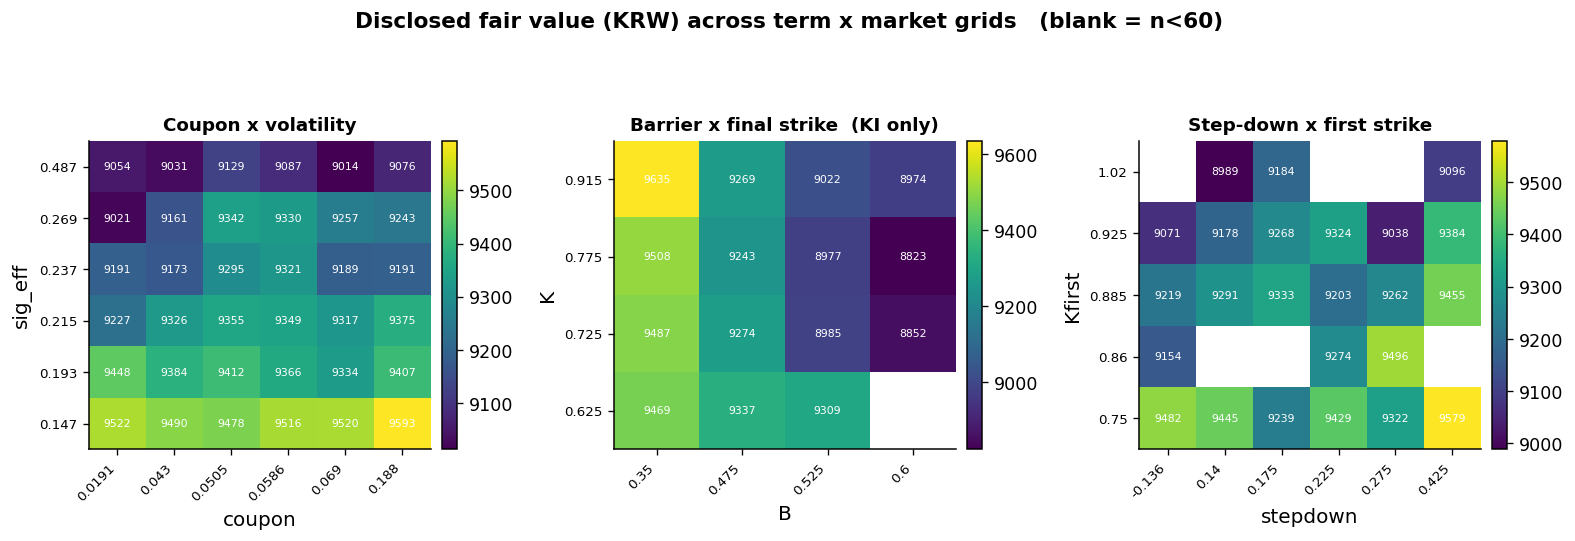

saved -> ct_interaction_2d.png


In [8]:
# 2D 히트맵: (coupon x vol), (B x K, KI only), (stepdown x Kfirst)
def grid2d(d, xc, yc, kx=6, ky=6, min_n=60):
    x = pd.qcut(d[xc].astype(float), kx, duplicates="drop")
    y = pd.qcut(d[yc].astype(float), ky, duplicates="drop")
    m = d.groupby([y, x], observed=True)["fair"].agg(["mean", "size"])
    M = m["mean"].unstack() * FACE
    N = m["size"].unstack()
    return M.where(N >= min_n), N

SPECS = [(df, "coupon", "sig_eff", "Coupon x volatility"),
         (KI, "B", "K", "Barrier x final strike  (KI only)"),
         (df, "stepdown", "Kfirst", "Step-down x first strike")]
fig, axs = plt.subplots(1, 3, figsize=(_plot.SLIDE_W, 4.6))
for a, (d, xc, yc, ttl) in zip(axs, SPECS):
    M, N = grid2d(d, xc, yc)
    im = a.imshow(M.values.astype(float), cmap="viridis", aspect="auto", origin="lower")
    a.set_xticks(range(M.shape[1]))
    a.set_xticklabels([f"{iv.mid:.3g}" for iv in M.columns], rotation=45, ha="right", fontsize=8)
    a.set_yticks(range(M.shape[0]))
    a.set_yticklabels([f"{iv.mid:.3g}" for iv in M.index], fontsize=8)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if not np.isnan(M.values[i, j]):
                a.text(j, i, f"{M.values[i, j]:.0f}", ha="center", va="center",
                       fontsize=6.5, color="white")
    a.set_xlabel(xc); a.set_ylabel(yc); a.set_title(ttl, fontsize=11)
    fig.colorbar(im, ax=a, fraction=.046, pad=.03)
fig.suptitle("Disclosed fair value (KRW) across term x market grids   (blank = n<60)",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(fm.image("ct_interaction_2d")); plt.show()
print("saved ->", fm.image("ct_interaction_2d").name)

## 12-7. 증분 안정성 종합 — 어떤 조건이 믿을 만한가

기준을 바꿔가며 얻은 증분들의 **부호 일관성**과 **크기 산포**로 조건을 줄세운다.

- `sign consistency` = 다수 부호를 따르는 그룹 비율 (1.0 이면 전 기준에서 부호가 같다)
- `|CV|` = 증분의 표준편차 / |평균| (작을수록 크기가 안정)
- `significant %` = 95% 구간이 0을 배제하는 그룹 비율

**부호가 뒤집히거나 CV 가 큰 조건은 데이터가 일관된 가격 규칙을 담고 있지 않다는 뜻**이고,
그런 항은 어떤 모형을 쓰더라도 증분을 안정적으로 재현하기 어렵다.


=== 증분 안정성 (부분증분, 전 기준 그룹 기준) ===
  [derived_of] 가 채워진 항은 원 조건의 함수 -> 독립 증거가 아니다

                          unit  derived_of  n_groups  mean_KRW  median_KRW  sd_KRW  sign_consistency  abs_CV  significant%
term                                                                                                                      
B                 barrier +5%p                    29  -151.658    -153.647  36.774             1.000   0.242       100.000
coupon             coupon +1%p                    31   -70.246     -66.911  27.546             1.000   0.392        96.774
cpn_spread  coupon spread +1%p  coupon - r        31   -70.246     -66.911  27.546             1.000   0.392        96.774
Kfirst       first strike +5%p                    31   -94.836     -97.912  37.298             1.000   0.393        96.774
nobs            +1 observation                    31    16.780      14.685  11.596             0.968   0.691        87.097
stepdown        step-down +5%p  Kfirst - K        31   -3

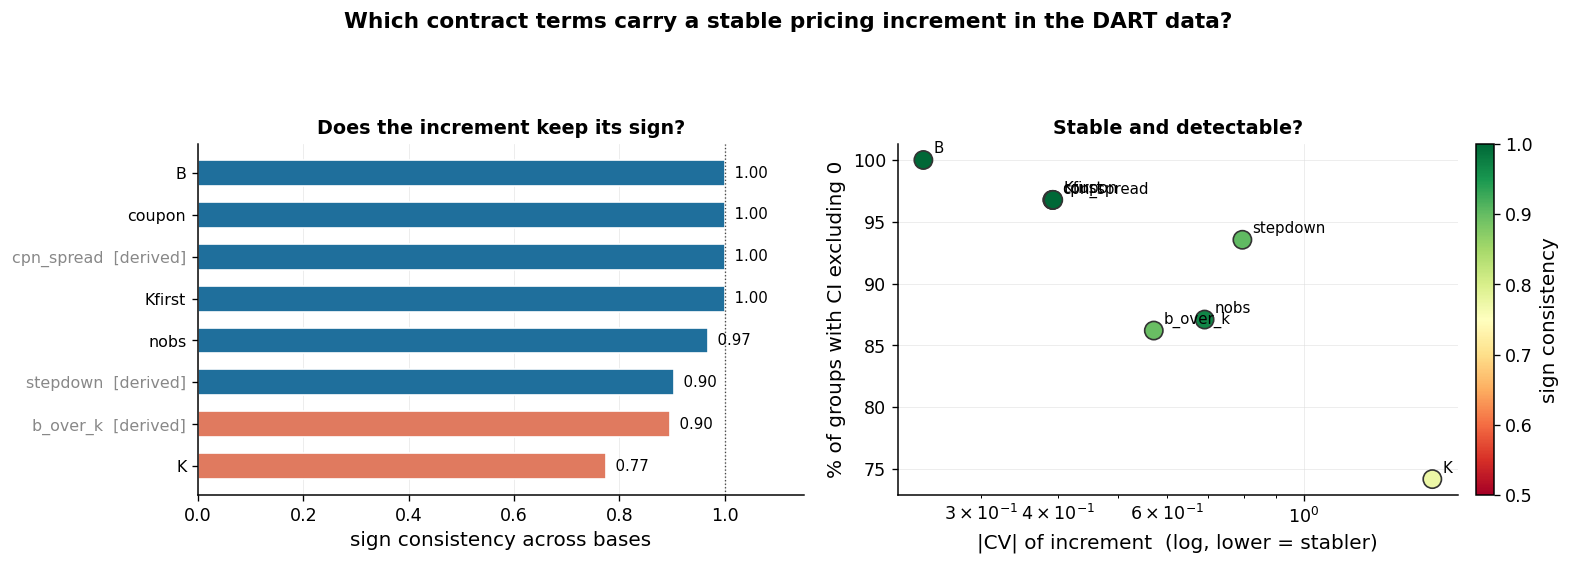

saved -> ct_stability.png | ct_stability.csv


In [9]:
# 안정성 스코어
PT = S[S.kind == "partial"]
rows = []
for t in TERMS:
    s = PT[PT.term == t].dropna(subset=["slope"])
    if len(s) < 4:
        continue
    b = s.slope.values; e = s.se.values
    maj = np.sign(np.median(b))
    rows.append({"term": t, "unit": UNIT[t][1], "derived_of": DERIVED_OF.get(t, ""),
                 "n_groups": len(s),
                 "mean_KRW": b.mean(), "median_KRW": float(np.median(b)),
                 "sd_KRW": b.std(ddof=1),
                 "sign_consistency": float((np.sign(b) == maj).mean()),
                 "abs_CV": float(b.std(ddof=1) / (abs(b.mean()) + 1e-9)),
                 "significant%": float((np.abs(b) > 1.96*e).mean()*100)})
ST = pd.DataFrame(rows).set_index("term")
ST = ST.sort_values(["sign_consistency", "abs_CV"], ascending=[False, True])
ST.to_csv(fm.stat("ct_stability"))
print("=== 증분 안정성 (부분증분, 전 기준 그룹 기준) ===")
print("  [derived_of] 가 채워진 항은 원 조건의 함수 -> 독립 증거가 아니다\n")
print(ST.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(_plot.SLIDE_W, 4.8))
y = np.arange(len(ST))
c = [_plot._QUAL[0] if v >= .9 else (_plot._QUAL[3] if v >= .7 else "#c0392b")
     for v in ST.sign_consistency]
ax[0].barh(y, ST.sign_consistency, .62, color=c, edgecolor="white")
for i, v in enumerate(ST.sign_consistency):
    ax[0].text(v, i, f"  {v:.2f}", va="center", fontsize=9)
ax[0].set_yticks(y)
ax[0].set_yticklabels([f"{t}{'  [derived]' if t in DERIVED_OF else ''}" for t in ST.index], fontsize=9.5)
for i, t in enumerate(ST.index):
    if t in DERIVED_OF:
        ax[0].get_yticklabels()[i].set_color("#888888")
ax[0].invert_yaxis()
ax[0].axvline(1.0, color="#444", lw=.8, ls=":")
ax[0].set_xlim(0, 1.15); ax[0].set_xlabel("sign consistency across bases")
ax[0].set_title("Does the increment keep its sign?", fontsize=11.5)
ax[0].grid(axis="x", color="#dddddd", lw=.5, alpha=.6)

sc = ax[1].scatter(ST.abs_CV, ST["significant%"], s=120,
                   c=ST.sign_consistency, cmap="RdYlGn", vmin=.5, vmax=1, edgecolor="#333")
for t, r in ST.iterrows():
    ax[1].annotate(t, (r.abs_CV, r["significant%"]), fontsize=9,
                   xytext=(6, 4), textcoords="offset points")
ax[1].set_xscale("log"); ax[1].set_xlabel("|CV| of increment  (log, lower = stabler)")
ax[1].set_ylabel("% of groups with CI excluding 0")
ax[1].set_title("Stable and detectable?", fontsize=11.5)
ax[1].grid(color="#dddddd", lw=.5, alpha=.6)
fig.colorbar(sc, ax=ax[1], fraction=.046, pad=.03, label="sign consistency")
fig.suptitle("Which contract terms carry a stable pricing increment in the DART data?",
             fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(fm.image("ct_stability")); plt.show()
print("saved ->", fm.image("ct_stability").name, "|", fm.stat("ct_stability").name)